In [27]:
import numpy as np
import pandas as pd
import cv2 as cv
import ffmpeg

import torch
import torch.nn as nn
import torchvision.models as models
import pytorch_lightning as pl

from ncps.torch import CfCCell
import struct

In [3]:
batch_size = 16 # placeholder well decide the actual value later
image_h=256
image_w=384
S=8
image_feature_size=960
hidden_size=512
backbone_units=1024
ts = torch.ones(batch_size)

In [4]:
class CoordConv(nn.Module):
   
    def __init__(self, in_channels, out_channels, kernel_size=1, padding=0):
        super().__init__()

        self.conv = nn.Conv2d(in_channels + 2, out_channels, kernel_size=kernel_size, padding=padding)

    def forward(self, x):
        batch_size, _, h, w = x.size()
        
    
        y_grid = torch.linspace(-1, 1, h, device=x.device).view(1, 1, h, 1).expand(batch_size, 1, h, w)
        x_grid = torch.linspace(-1, 1, w, device=x.device).view(1, 1, 1, w).expand(batch_size, 1, h, w)
        
        
        x_coord = torch.cat([x, y_grid, x_grid], dim=1)
        return self.conv(x_coord)

In [5]:
class GazeLLNArch(pl.LightningModule):

    def __init__(self, image_h: int = 256, image_w: int = 384, S: int = 8, 
                 hidden_size: int = 512, backbone_units: int = 1024):
        super().__init__()
        
        self.save_hyperparameters()

        
        self.hmap_h = self.hparams.image_h // self.hparams.S
        self.hmap_w = self.hparams.image_w // self.hparams.S
        self.hmap_feature_size = self.hmap_h * self.hmap_w

        
        mobilenet = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
        self.feature_extractor = mobilenet.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.image_feature_size = 960 

        
        self.coordconv = CoordConv(in_channels=1, out_channels=1, kernel_size=3, padding=1)

        
        cfc_input_size = self.image_feature_size + self.hmap_feature_size
        self.cfc_cell = CfCCell(
            input_size=cfc_input_size,
            hidden_size=self.hparams.hidden_size,
            backbone_activation="lecun_tanh",
            backbone_units=self.hparams.backbone_units,
            backbone_layers=1
        )
        
        
        self.project = nn.Linear(self.hparams.hidden_size, self.hmap_feature_size)

    def forward(self, image, prev_hmap, hx, ts):
        """
        Args:
            image: Visual stimulus tensor of shape (B, 3, H, W)
            prev_hmap: Previous fixation heatmap of shape (B, hmap_h, hmap_w) or (B, 1, hmap_h, hmap_w)
            hx: Hidden state tensor for the CfCCell
            ts: Elapsed time timespan tensor of shape (B,)
        """
        
        vis_features = self.feature_extractor(image)
        vis_features = self.pool(vis_features).flatten(1)  # Shape: (B, 960)

        # Ensure prev_hmap has a channel dimension (B, 1, hmap_h, hmap_w)
        if prev_hmap.dim() == 3:
            prev_hmap = prev_hmap.unsqueeze(1)
            
    
        # hmap_coords = self.coordconv(prev_hmap).flatten(1)
        hmap_coords = prev_hmap.flatten(1) # Shape: (B, hmap_h * hmap_w) (using coordconv before flattenning might be useless)
        
        
        x = torch.cat([vis_features, hmap_coords], dim=1)
        x, hx = self.cfc_cell(x, hx, ts)
        
        
        out_hmap = self.project(x)

        
        out_hmap = out_hmap.view(-1, self.hmap_h, self.hmap_w)
        

        return out_hmap, hx

In [6]:
def SoftmaxMap(out_hmap,hmap_h,hmap_w):
    out_hmap = torch.softmax(out_hmap.flatten(1), dim=1).view(-1, hmap_h, hmap_w)
    return out_hmap

In [7]:
# Sample Forward Pass Test

# Instantiating the model
model = GazeLLNArch(
    image_h=256,
    image_w=384,
    S=8,
    hidden_size=512,
    backbone_units=1024
)
model.eval()  # puts model in inference mode, disables dropout etc.

# Creating dummy inputs matching expected shapes
B = 16  # using smaller batch size

dummy_image   = torch.randn(B, 3, 256, 384)        # (B, C, H, W)
dummy_hmap    = torch.zeros(B, 256//8, 384//8)     # (B, hmap_h, hmap_w) = (B, 32, 48)
dummy_hx      = torch.zeros(B, 512)                # (B, hidden_size)
dummy_ts      = torch.ones(B, 1)                   # (B,) elapsed time, all 1s for now

# Running one forward pass
with torch.no_grad():  # don't compute gradients during testing
    out_hmap, new_hx = model(dummy_image, dummy_hmap, dummy_hx, dummy_ts)

# Checking output shapes
print("Output heatmap shape:", out_hmap.shape)   # should be (16, 32, 48)
print("New hidden state shape:", new_hx.shape)   # should be (16, 512)

Output heatmap shape: torch.Size([16, 32, 48])
New hidden state shape: torch.Size([16, 512])


In [8]:
class Video_Preprocess:

    def __init__(self, video_path, fps):
        self.video_path = video_path
        self.fps = fps

        self.vid = cv.VideoCapture(video_path)
        
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

        self.width = 384
        self.height = 256
        
    def Get_frame(self):
        curr_ret, curr_frame = self.vid.read()

        if curr_ret == False:
            return curr_ret, curr_frame
        
        curr_frame = cv.cvtColor(curr_frame, cv.COLOR_BGR2RGB)

        curr_frame = torch.tensor(curr_frame).permute(2, 0, 1).float()              # (H,W,C) -> (C,H,W)

        # Image Normalization
        curr_frame = curr_frame / 255.0                                             # scaling to [0, 1]
        curr_frame = (curr_frame - self.mean) / self.std
        
        curr_frame = curr_frame.unsqueeze(0)                                        # (C,H,W) -> (1,C,H,W)

        return curr_ret, curr_frame

    def video_formatting(self):
        (ffmpeg
        .input(self.video_path)
        .filter('fps', fps = self.fps, round = 'up')
        .filter('scale', self.width, self.height)
        .output("24_fps_video.mp4",
                vcodec='libx264rgb',
                pix_fmt='rgb24'
                )
        .overwrite_output()
        .run()
        )

    def video_to_frames(self):
        self.video_formatting()
        frames_list = []
        while True:
            ret, frame = self.Get_frame()
            if not ret:
                break
            frames_list.append(frame)           # Shape: (number of frames, Batch size, Channel, Height, Width)

        return frames_list


In [9]:
frames = Video_Preprocess("sample_video.mp4", 24).video_to_frames()

In [10]:
import os
import random
from typing import Tuple, List, Dict, Optional

import numpy as np
import scipy.io as sio
from PIL import Image
from scipy.ndimage import gaussian_filter

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms    

In [11]:
def _gaussian_heatmap(
    x: float,
    y: float,
    img_w: int,
    img_h: int,
    hmap_w: int,
    hmap_h: int,
    sigma: float = 1.5,
) -> np.ndarray:
    """
    Place a Gaussian blob at pixel (x, y) on a downsampled heatmap grid.

    Args:
        x, y      : fixation location in *original* image pixel coordinates
        img_w/h   : original image size (before downsampling)
        hmap_w/h  : heatmap size (= img / downsample)
        sigma     : Gaussian std-dev in heatmap pixels

    Returns:
        hmap : (hmap_h, hmap_w) float32 array summing to 1
    """
    hmap = np.zeros((hmap_h, hmap_w), dtype=np.float32)

    # scale fixation coords to heatmap space
    xi = int(round(x * hmap_w / img_w))
    yi = int(round(y * hmap_h / img_h))

    xi = np.clip(xi, 0, hmap_w - 1)
    yi = np.clip(yi, 0, hmap_h - 1)

    hmap[yi, xi] = 1.0
    hmap = gaussian_filter(hmap, sigma=sigma)

    total = hmap.sum()
    if total > 0:
        hmap /= total   

    return hmap

In [12]:
def _pad_or_truncate(
    seq: List,
    max_len: int,
    pad_value,
) -> Tuple[List, List[bool]]:
    """Truncate to max_len and return (padded_seq, mask).
    mask[i] = True  →  real fixation
    mask[i] = False →  padding (loss should ignore these)
    """
    real_len = min(len(seq), max_len)
    mask = [True] * real_len + [False] * (max_len - real_len)
    seq = seq[:real_len] + [pad_value] * (max_len - real_len)
    return seq, mask

In [13]:
def extract_scanpaths(
    entry: Dict,
    min_len: int = 4,
    max_len: int = 8,
) -> List[Dict]:
    """
    Extract per-subject scanpaths from one OSIE entry.

    Returns a list of dicts, each with keys:
        img_name  : str
        fix_x     : list[float]  (length <= max_len)
        fix_y     : list[float]
        fix_dt    : list[float]  (durations in ms)
        mask      : list[bool]   (True = real, False = padding)
    """
    scanpaths = []
    img_name = entry['img']

    for subj in entry['subjects']:
        xs  = np.atleast_1d(np.array(subj['fix_x'],        dtype=np.float32)).tolist()
        ys  = np.atleast_1d(np.array(subj['fix_y'],        dtype=np.float32)).tolist()
        dts = np.atleast_1d(np.array(subj['fix_duration'], dtype=np.float32)).tolist()

        if len(xs) < min_len:
            continue  # discard short scanpaths per GazeLNN / tSPM-Net

        xs, mask = _pad_or_truncate(xs, max_len, pad_value=xs[-1])
        ys, _    = _pad_or_truncate(ys, max_len, pad_value=ys[-1])
        dts, _   = _pad_or_truncate(dts, max_len, pad_value=0.0)

        scanpaths.append({
            'img_name': img_name,
            'fix_x':    xs,
            'fix_y':    ys,
            'fix_dt':   dts,
            'mask':     mask,
        })

    return scanpaths

In [14]:
class OSIEDataset(Dataset):
    """
    PyTorch Dataset for OSIE scanpath prediction.

    Each item is one (image, scanpath) pair — one subject's viewing of one
    image.  With 700 images × ~15 subjects the dataset has ~10 500 items
    before filtering.

    Args:
        data_root   : path to the osie/ folder containing stimuli/ and eye/
        split       : 'train' | 'val' | 'test'
        img_size    : (H, W) to resize images to. GazeLNN uses (256, 384).
        downsample  : spatial downsampling factor for heatmaps.
                      heatmap size = (img_size[0]//ds, img_size[1]//ds)
        min_len     : discard scanpaths shorter than this
        max_len     : truncate/pad scanpaths to this length
        sigma       : Gaussian std-dev (in heatmap pixels) for fixation blobs
        seed        : random seed for the 80/10/10 image split
    """

    # 80 / 10 / 10  image-level split (consistent with the paper)
    SPLIT_RATIOS = {'train': 0.80, 'val': 0.10, 'test': 0.10}

    def __init__(
        self,
        data_root: str,
        split: str = 'train',
        img_size: Tuple[int, int] = (256, 384),
        downsample: int = 8,
        min_len: int = 4,
        max_len: int = 8,
        sigma: float = 1.5,
        seed: int = 42,
    ):
        assert split in ('train', 'val', 'test')
        self.stimuli_dir = os.path.join(data_root, 'stimuli')
        self.img_size    = img_size          # (H, W)
        self.hmap_size   = (img_size[0] // downsample, img_size[1] // downsample)
        self.max_len     = max_len
        self.sigma       = sigma

        # ---- load fixations ------------------------------------------------
        mat_path = os.path.join(data_root, 'eye', 'fixations.mat')
        raw = sio.loadmat(mat_path, simplify_cells=True)
        all_entries = raw['fixations']          # length 700

        # ---- deterministic image-level split --------------------------------
        n_total = len(all_entries)
        indices = list(range(n_total))
        rng = random.Random(seed)
        rng.shuffle(indices)

        n_train = int(n_total * 0.80)
        n_val   = int(n_total * 0.10)

        if split == 'train':
            chosen = indices[:n_train]
        elif split == 'val':
            chosen = indices[n_train : n_train + n_val]
        else:
            chosen = indices[n_train + n_val:]

        # ---- flatten to (image, subject) scanpath pairs --------------------
        self.samples: List[Dict] = []
        for idx in chosen:
            entry = all_entries[idx]
            scanpaths = extract_scanpaths(entry, min_len=min_len, max_len=max_len)
            self.samples.extend(scanpaths)

        # ---- image transforms ----------------------------------------------
        self.transform = transforms.Compose([
            transforms.Resize(img_size),          # PIL Resize takes (H, W)
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],       # ImageNet stats
                std =[0.229, 0.224, 0.225],
            ),
        ])

        print(
            f"[OSIEDataset] split={split:5s} | "
            f"images={len(chosen)} | scanpath pairs={len(self.samples)}"
        )

    
    def __len__(self) -> int:
        return len(self.samples)

    
    def __getitem__(self, idx: int):
        sample   = self.samples[idx]
        img_H, img_W = self.img_size
        hmap_H, hmap_W = self.hmap_size

        #  load & transform image 
        img_path = os.path.join(self.stimuli_dir, sample['img_name'])
        img = Image.open(img_path).convert('RGB')

        # original size needed to scale fixation coords
        orig_W, orig_H = img.size   # PIL gives (W, H)

        img_tensor = self.transform(img)   # (3, H, W)

        # ---- build heatmap sequence ----------------------------------------
        heatmap_seq = []
        for i in range(self.max_len):
            if sample['mask'][i]:
                hmap = _gaussian_heatmap(
                    x=sample['fix_x'][i],
                    y=sample['fix_y'][i],
                    img_w=orig_W,
                    img_h=orig_H,
                    hmap_w=hmap_W,
                    hmap_h=hmap_H,
                    sigma=self.sigma,
                )
            else:
                # padding step — zero heatmap
                hmap = np.zeros((hmap_H, hmap_W), dtype=np.float32)

            heatmap_seq.append(hmap)

        heatmap_seq = torch.from_numpy(
            np.stack(heatmap_seq, axis=0)
        )  # (T, hmap_H, hmap_W)

        # ---- fixation durations (∆t for CfC) --------------------------------
        dt_seq = torch.tensor(sample['fix_dt'], dtype=torch.float32)  # (T,)

        # first fixation ∆t = 0 per the paper
        dt_seq[0] = 0.0

        # ---- padding mask ---------------------------------------------------
        mask = torch.tensor(sample['mask'], dtype=torch.bool)  # (T,)

        return img_tensor, heatmap_seq, dt_seq, mask

In [15]:
def build_dataloaders(
    data_root: str,
    img_size: Tuple[int, int] = (256, 384),
    downsample: int = 8,
    min_len: int = 4,
    max_len: int = 8,
    sigma: float = 1.5,
    batch_size: int = 8,
    num_workers: int = 4,
    seed: int = 42,
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """
    Returns (train_loader, val_loader, test_loader).

    Each batch yields:
        imgs         : (B, 3, H, W)       — normalised image tensor
        heatmap_seq  : (B, T, Hd, Wd)     — per-fixation Gaussian heatmaps
        dt_seq       : (B, T)             — fixation durations in ms
        padding_mask : (B, T)             — True where fixation is real
    """
    kwargs = dict(
        data_root  = data_root,
        img_size   = img_size,
        downsample = downsample,
        min_len    = min_len,
        max_len    = max_len,
        sigma      = sigma,
        seed       = seed,
    )

    train_ds = OSIEDataset(split='train', **kwargs)
    val_ds   = OSIEDataset(split='val',   **kwargs)
    test_ds  = OSIEDataset(split='test',  **kwargs)

    loader_kwargs = dict(
        batch_size  = batch_size,
        num_workers = num_workers,
        pin_memory  = True,
    )

    train_loader = DataLoader(train_ds, shuffle=True,  **loader_kwargs)
    val_loader   = DataLoader(val_ds,   shuffle=False, **loader_kwargs)
    test_loader  = DataLoader(test_ds,  shuffle=False, **loader_kwargs)

    return train_loader, val_loader, test_loader

[OSIEDataset] split=train | images=560 | scanpath pairs=8376
[OSIEDataset] split=val   | images=70 | scanpath pairs=1047
[OSIEDataset] split=test  | images=70 | scanpath pairs=1047
imgs        : torch.Size([2, 3, 256, 384])
heatmap_seq : torch.Size([2, 8, 32, 48])
dt_seq      : torch.Size([2, 8])
mask        : torch.Size([2, 8])
mask[0]     : tensor([True, True, True, True, True, True, True, True])


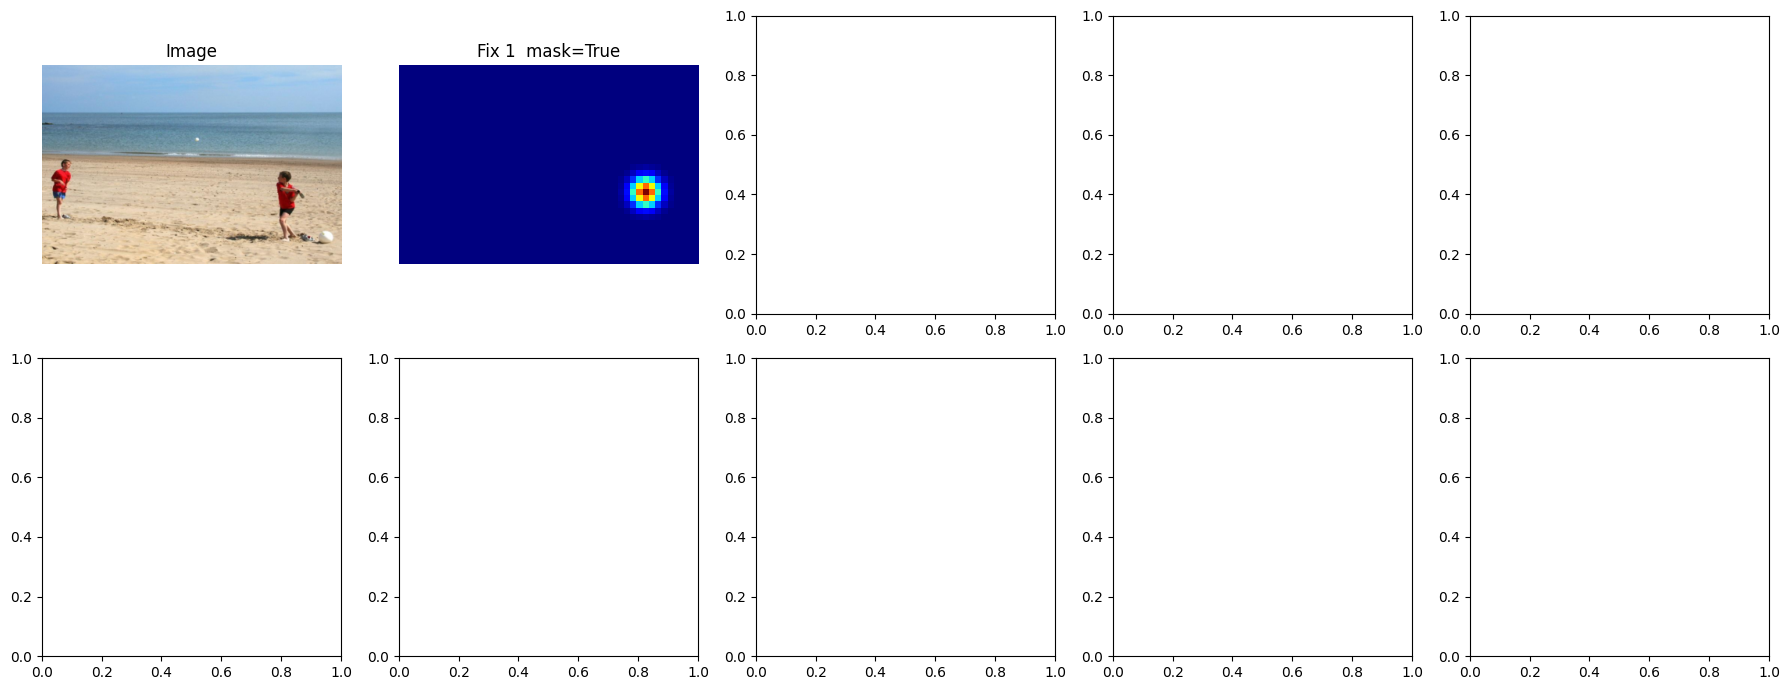

Saved osie_sample.png


<Figure size 640x480 with 0 Axes>

Saved osie_sample.png


<Figure size 640x480 with 0 Axes>

Saved osie_sample.png


...

Saved osie_sample.png


<Figure size 640x480 with 0 Axes>

Saved osie_sample.png


<Figure size 640x480 with 0 Axes>

Saved osie_sample.png


In [25]:
import matplotlib.pyplot as plt
DATA_ROOT = 'OSIE'
train_loader, val_loader, test_loader = build_dataloaders(
        data_root  = DATA_ROOT,
        img_size   = (256, 384),
        downsample = 8,
        batch_size = 2,
        num_workers= 0,
    )

imgs, hmap_seq, dt_seq, mask = next(iter(train_loader))

print("imgs        :", imgs.shape)       # (2, 3, 256, 384)
print("heatmap_seq :", hmap_seq.shape)   # (2, 8, 32, 48)
print("dt_seq      :", dt_seq.shape)     # (2, 8)
print("mask        :", mask.shape)       # (2, 8)
print("mask[0]     :", mask[0])

    # visualise first image + its 8 fixation heatmaps
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
img_vis = (imgs[0] * std + mean).permute(1, 2, 0).numpy()
img_vis = np.clip(img_vis, 0, 1)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes[0, 0].imshow(img_vis)
axes[0, 0].set_title('Image')
axes[0, 0].axis('off')

for t in range(8):
    ax = axes[(t + 1) // 5, (t + 1) % 5]
    ax.imshow(hmap_seq[0, t].numpy(), cmap='jet', vmin=0)
    ax.set_title(f'Fix {t+1}  mask={mask[0,t].item()}')
    ax.axis('off')

    plt.tight_layout()
    plt.savefig('osie_sample.png', dpi=120)
    plt.show()
    print("Saved osie_sample.png")

In [26]:
# Setting up the qp offset map

def mb_grid(native_width = 1920, native_height = 1080):
    """
    Prepares the macroblock grid.

    Args:
        native_width: The width of the original frame
        native_height: The height of the original frame
    """

    # Can try to implement this using numpy functions
    num_mb_width = (native_width + 15) // 16            # number of horizontal macroblock in integer format
    num_mb_height = (native_height + 15) // 16          # number of vertical macroblock in integer format

    return num_mb_width, num_mb_height

def QP_map(hmap, num_mb_width, num_mb_height):
    """
    Prepares the QP map.

    Args:
        hmap: The input heatmap - Shape: (B, hmap_h, hmap_w)
        num_mb_width: The number of horizontal macroblocks
        num_mb_height: The number of vertical macroblocks
    """

    # Resizing the heatmap to match the macroblock grid
    resized_hmap = torch.nn.functional.interpolate(hmap.unsqueeze(1),
                                                    size=(int(num_mb_height), int(num_mb_width)),
                                                    mode='bilinear',
                                                    align_corners=False)
    # Shape: (B, 1, num_mb_height, num_mb_width) Ensure B = 1
    
    resized_hmap = resized_hmap / resized_hmap.max()            # Converts the softmax into probabilities

    return resized_hmap.squeeze(1).squeeze(0)  # Removing the channel and batch dimension -> Shape: (num_mb_height, num_mb_width)

def QP_offseter(qp_map, q_high = 0.6, q_low = -1):

    # q values -> (-1, 1) where -1 = highest quality and 1 = very high compression

    qp_offset_map = q_high + qp_map*(q_low - q_high)          # Shape: (num_mb_height, num_mb_width)
    qp_offset_map = torch.clamp(qp_offset_map, min=-1.0, max=1.0)

    return qp_offset_map.cpu().numpy()

def byte_packing(qp_offset_map, native_width, native_height):

    roi_array = bytearray()

    for y in range(0, qp_offset_map.shape[0]):
        for x in range(0, qp_offset_map.shape[1]):
            val = qp_offset_map[y, x]
            denominator = 10000
            numerator = int(val * 10000)
            roi_array.extend(struct.pack('Iiiiiii', 
                        28, 
                        y*16,
                        min ((y + 1)*16, native_height), 
                        x*16 , min((x + 1)* 16, native_width), 
                        numerator, 
                        denominator))

    return bytes(roi_array)

In [ ]:
class Video_pipeline:

    def __init__(self, input_video_path, fps):
        self.video_path = input_video_path
        self.fps = fps


        self.frames = Video_Preprocess(self.video_path, self.fps).video_to_frames()

    def qp_map_calc(self):
        mb_grid()